In [1]:
"""
Mean Teacher (Consistency Regularization)
- Student Model -> augmented view 1 -> logit_s
- Teacher Model -> augmented view 2 -> logit_t (EMA로 update)

Loss = supervised_loss(labeled) + lambda * consistency_loss(unlabeled)
"""

'\nMean Teacher (Consistency Regularization)\n- Student Model -> augmented view 1 -> logit_s\n- Teacher Model -> augmented view 2 -> logit_t (EMA로 update)\n\nLoss = supervised_loss(labeled) + lambda * consistency_loss(unlabeled)\n'

In [2]:
from torchvision import models
from torchvision.models import vit_b_16

print("=" * 60)

try:
    m1 = models.resnet50(weights=None)
    print("ResNet50 build success")
except Exception as e:
    print("Fail", e)

try:
    m2 = vit_b_16(weights=None)
    print("Vit-B/16 build success")
except Exception as e:
    print("Fail",e)

print("=" * 60)

ResNet50 build success
Vit-B/16 build success


In [3]:
# 1. Import & Settings
import os
import gc
import random
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_auc_score, recall_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.backends.cudnn.benchmark = True

Device: cuda


In [4]:
#2. Hyperparameters & Paths
DATA_ROOT = Path("/tf/nasw/dataset001/preprocessed/npz_ct")
TABULAR_CSV_PATH = Path("/tf/nasw/dataset001/preprocessed/stage1_clinical_dataset.csv")

FOLDS = [1, 2, 3, 4, 5]

OUTPUT_DIR = Path("./ct_recurrence_models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DIR = Path("./ct_recurrence_figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 4
NUM_WORKERS = 2
NUM_EPOCHS = 30
LR = 5e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 10

USE_SLICE_SUBSAMPLING = False

# Mean Teacher hyperparameter
EMA_DECAY = 0.999
CONSISTENCY_WEIGHT = 1.0
CONSISTENCY_RAMPUP = 10
CONFIDENCE_THRESHOLD = 0.0

print("DATA_ROOT:", DATA_ROOT)
print("TABULAR_CSV_PATH:", TABULAR_CSV_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("FIGURE_DIR:", FIGURE_DIR.resolve())
print("FOLDS:", FOLDS)

DATA_ROOT: /tf/nasw/dataset001/preprocessed/npz_ct
TABULAR_CSV_PATH: /tf/nasw/dataset001/preprocessed/stage1_clinical_dataset.csv
OUTPUT_DIR: /tf/notebooks/Image Encoder/Untitled Folder/ct_recurrence_models
FIGURE_DIR: /tf/notebooks/Image Encoder/Untitled Folder/ct_recurrence_figures
FOLDS: [1, 2, 3, 4, 5]


In [5]:
def inspect_fold_npz(fold_idx):
    train_npz_path = DATA_ROOT / f"fold_{fold_idx}_train.npz"
    val_npz_path = DATA_ROOT / f"fold_{fold_idx}_val.npz"

    print("TRAIN:", train_npz_path, train_npz_path.exits())
    print("VAL:", val_npz_path, val_npz_path.exists())

    train_npz = np.load(train_npz_path, allow_pickle=False, mmap_mode="r")
    val_npz = np.load(val_npz_path, allow_pickle=False, mmap_mode="r")

    for k in train_npz.files:
        print(f"[train] {k}: shape={train_npz[k].shape}, dtype={train_npz[k].dtype}")
    for k in val_npz.files:
        print(f"[val] {k}: shape={val_npz[k].shape}, dtype={val_npz[k].dtype}")

In [6]:
# local pretrained weight paths
LOCAL_RESNET50_IMAGENET_WEIGHTS = Path("/tf/pretrained_model/resnet50-11ad3fa6.pth")
LOCAL_VIT_WEIGHTS = Path("/tf/pretrained_model/vit_b_16-c867db91.pth")

print("LOCAL_RESNET50_IMAGENET_WEIGHTS exists:", LOCAL_RESNET50_IMAGENET_WEIGHTS.exists())
print("LOCAL_VIT_WEIGHTS exists:", LOCAL_VIT_WEIGHTS.exists())

LOCAL_RESNET50_IMAGENET_WEIGHTS exists: True
LOCAL_VIT_WEIGHTS exists: True


In [7]:
def load_local_state_dict(weight_path):
    weight_path = Path(weight_path)
    assert weight_path.exists(), f"Weight file not found: {weight_path}"

    ckpt = torch.load(weight_path, map_location="cpu")

    if isinstance(ckpt, dict) and "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
        ckpt = ckpt["state_dict"]

    return ckpt

In [8]:
def compute_binary_metrics(y_true, y_prob, threshold = 0.5):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(float)
    y_pred = (y_prob > threshold).astype(int)

    unique_classes = np.unique(y_true)
    if len(unique_classes) < 2:
        auc = 0.5
    else:
        try:
            auc = roc_auc_score(y_true, y_prob)
        except ValueError:
            auc = 0.5

    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "auc": auc,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "cm": confusion_matrix(y_true, y_pred)
    }
    return metrics

In [9]:
def maybe_subsample_slices(x, is_train=True):
    if not USE_SLICE_SUBSAMPLING:
        return x

    S = x.shape[0]
    if S <= MAX_SLICES:
        return x

    if is_train:
        idx = np.sort(np.random.choice(S, size = MAX_SLICES, replace=False))
    else:
        idx = np.linspace(0, S-1, MAX_SLICES).round().astype(int)

    return x[idx]

def print_gpu_mem(prefix=""):
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / (1024 ** 3)
        reserv = torch.cuda.memory_reserved() / (1024 ** 3)
        print(f"{perfix} GPU alloc = {alloc:.2f} GB | reserved = {reserv:.2f} GB")

In [10]:
#TABULAR 파일 로드
TABULAR_STAGE1_DF = pd.read_csv(TABULAR_CSV_PATH)
TABULAR_STAGE1_DF["PT_ID"] = TABULAR_STAGE1_DF["PT_ID"].astype(str)

TABULAR_META_COLS = ["PT_ID", "fold", "split", "label"]
TABULAR_STAGE1_FEATURES = [c for c in TABULAR_STAGE1_DF.columns if c not in TABULAR_META_COLS]

# 1) bool -> int
bool_cols = TABULAR_STAGE1_DF[TABULAR_STAGE1_FEATURES].select_dtypes(include=["bool"]).columns.tolist()
for col in bool_cols:
    TABULAR_STAGE1_DF[col] = TABULAR_STAGE1_DF[col].astype(np.int8)

# 2) object 칼럼 처리
obj_cols = TABULAR_STAGE1_DF[TABULAR_STAGE1_FEATURES].select_dtypes(include=["object"]).columns.tolist()
for col in obj_cols:
    s = TABULAR_STAGE1_DF[col].astype(str).str.strip()

    lower_vals = set(s.dropna().str.lower().unique().tolist())

    if lower_vals.issubset({"True", "False"}):
        TABULAR_STAGE1_DF[col] = s.str.lower().map({"True":1, "False":0}).astype(np.int8)
    elif lower_vals.issubset({"0", "1"}):
        TABULAR_STAGE1_DF[col] = pd.to_numeric(s, error="raise").astype(np.int8)

    else:
        print(f"[WARN]아직 문자열 범주가 남아있는 컬럼: {col}")
        print("sample unique:", s.dropna().unique()[:10])


print("TABULAR_STAGE1_DF:", TABULAR_STAGE1_DF.shape)
print("TABULAR_STAGE1_FEATURES:", len(TABULAR_STAGE1_FEATURES))
print("tabular example cols:", TABULAR_STAGE1_FEATURES)

non_numeric_cols = TABULAR_STAGE1_DF[TABULAR_STAGE1_FEATURES].select_dtypes(exclude=[np.number]).columns.tolist()
print("tabular non_numeric_cols:", non_numeric_cols)

missing_total = TABULAR_STAGE1_DF[TABULAR_STAGE1_FEATURES].isna().sum().sum()
print("tabular missing values:", missing_total)

assert len(non_numeric_cols) == 0, f"csv에 numeric이 아닌 컬럼이 있습니다: {non_numeric_cols[:20]}"
assert missing_total == 0, "CSV에 결측치가 있습니다"

TABULAR_STAGE1_DF: (12810, 14)
TABULAR_STAGE1_FEATURES: 10
tabular example cols: ['recurrence', 'Birth_YM', 'SONO_YM', 'PT_height', 'DIAG_ATT_AGE', 'CA_125', 'PT_GVD', 'PT_weight', 'CT_YM', 'PT_Para']
tabular non_numeric_cols: []
tabular missing values: 0


In [11]:
print(TABULAR_STAGE1_DF[["PT_ID", "fold", "split", "label"]].head())
print(TABULAR_STAGE1_DF["split"].value_counts(dropna=False))
print(TABULAR_STAGE1_DF["fold"].value_counts(dropna=False).sort_index())
print(TABULAR_STAGE1_DF["label"].value_counts(dropna=False).sort_index())

   PT_ID  fold  split  label
0  10008     1    val      1
1  10008     2  train      1
2  10008     3  train      1
3  10008     4  train      1
4  10008     5  train      1
split
train    10248
val       2562
Name: count, dtype: int64
fold
1    2562
2    2562
3    2562
4    2562
5    2562
Name: count, dtype: int64
label
0    10035
1     2775
Name: count, dtype: int64


In [12]:
def augment_slices(x):
    """
    x: (S, C, H, W) float tensor, 이미 정규화된 상태
    기하학적 + 강도 변환 적용
    """
    S = x.shape[0]
    
    # 1. 수평 플립
    if random.random() > 0.5:
        x = torch.flip(x, dims=[3])

    # 2. 회전 +- 10도
    if random.random() > 0.3:
        angle = random.uniform(-10, 10)
        S = x.shape[0]
        x = torch.stack([
            TF.rotate(x[i], angle) for i in range(S)
        ])

    # 3. 랜덤 크롭 + 리사이즈
    if random.random() > 0.5:
        H, W = x.shape[2], x.shape[3]
        scale = random.uniform(0.9, 1.0)
        crop_h = int(H * scale)
        crop_w = int(W * scale)
        top = random.randint(0, H - crop_h)
        left = random.randint(0, W - crop_w)
        x = x[:, :, top:top+crop_h, left:left+crop_w]
        x = torch.nn.functional.interpolate(
            x, size=(H, W),
            mode="bilinear",
            align_corners=False
        )

    # 4. 밝기/대비 조정 
    if random.random() > 0.5:
        brightness = random.uniform(-0.1, 0.1)
        x = x + brightness
    if random.random() > 0.5:
        contrast = random.uniform(0.9, 1.1)
        x = x * contrast
        
    # 5. 가우시안 노이즈 
    if random.random() > 0.5:
        noise = torch.randn_like(x) * 0.01
        x = x + noise

    # 6. 슬라이스 드롭아웃
    if random.random() > 0.7 and S > 4:
        n_drop = random.randint(1, max(1, S // 10))
        drop_idx = random.sample(range(S), n_drop)
        x[drop_idx] = 0.0
    
    return x

def augment_tabular(tab, noise_std=0.01):
    """
    tab: (feature_dim,) float tensor
    학습 시 임상 피처에 미세한 가우시안 노이즈 추가
    """
    if random.random() > 0.5:
        noise = torch.randn_like(tab) * noise_std
        tab = tab + noise
    return tab

# Labeled Dataset (recurrence 0 / 1)
class LabledCTTabularNPZDataset(Dataset):
    def __init__(self, npz_path, tabular_df, is_train=False):
        super().__init__()
        self.is_train = is_train
        self.npz = np.load(npz_path, allow_pickle=False, mmap_mode="r")

        self.images = self.npz["images"]
        self.labels = self.npz["labels"].astype(np.float32)
        self.patient_ids = np.array([str(x) for x in self.npz["patient_ids"]])
        self.mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

        tab_df = tabular_df.copy()
        tab_df["PT_ID"] = tab_df["PT_ID"].astype(str)

        feature_cols = [c for c in tab_df.columns 
                        if c not in ["PT_ID", "fold", "split", "label", "recurrence"]]
        self.feature_cols = feature_cols

        # PT_ID -> (tabular_feat, recurrence_label) 매핑
        tab_map = {}
        for _, row in tab_df.iterrows():
            pid = str(row["PT_ID"])
            rec = float(row["recurrence"])
            feat = row[feature_cols].values.astype(np.float32)
            tab_map[pid] = (feat, rec)

        valid_indices = []
        valid_tab_feats = []
        valid_labels = []
        mismatch_count = 0

        for i, pid in enumerate(self.patient_ids):
            if pid not in tab_map:
                continue

            feat, rec_label = tab_map[pid]

            if rec_label < 0:
                continue

            valid_indices.append(i)
            valid_tab_feats.append(feat)
            valid_labels.append(rec_label)

        self.indices = np.array(valid_indices, dtype=np.int64)
        self.tabular_feats = (
            np.stack(valid_tab_feats, axis = 0)
            if len(valid_tab_feats) > 0
            else np.zeros((0, len(feature_cols)), dtype=np.float32)
        )
        self.rec_labels = np.array(valid_labels, dtype=np.float32)
        

        print(f"  [Labeled] total matched: {len(self.indices)} "
              f"(pos={int(self.rec_labels.sum())}, "
              f"neg={int((self.rec_labels==0).sum())})")
        

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        
        x = self.images[real_idx]
        y = self.rec_labels[idx]
        tab = self.tabular_feats[idx]

        x = torch.from_numpy(x).float().permute(0, 3, 1, 2).contiguous()
        x = x / 255.0
        x = maybe_subsample_slices(x, is_train=self.is_train)
        x = (x-self.mean) / self.std

        tab = torch.tensor(tab, dtype=torch.float32)

        if self.is_train:
            x = augment_slices(x)
            tab = augment_tabular(tab)

        y = torch.tensor([y], dtype=torch.float32)

        return x, tab, y

# Unlabeled Dataset (recurrence -1)
class UnlabledCTTabularNPZDataset(Dataset):
    def __init__(self, npz_path, tabular_df):
        super().__init__()
        self.is_train = True
        self.npz = np.load(npz_path, allow_pickle=False, mmap_mode="r")

        self.images = self.npz["images"]
        self.patient_ids = np.array([str(x) for x in self.npz["patient_ids"]])
        self.mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

        tab_df = tabular_df.copy()
        tab_df["PT_ID"] = tab_df["PT_ID"].astype(str)

        feature_cols = [c for c in tab_df.columns 
                        if c not in ["PT_ID", "fold", "split", "label", "recurrence"]]
        self.feature_cols = feature_cols

        # PT_ID -> (tabular_feat, recurrence_label) 매핑
        tab_map = {}
        for _, row in tab_df.iterrows():
            pid = str(row["PT_ID"])
            rec = float(row["recurrence"])
            feat = row[feature_cols].values.astype(np.float32)
            tab_map[pid] = (feat, rec)

        valid_indices = []
        valid_tab_feats = []


        for i, pid in enumerate(self.patient_ids):
            if pid not in tab_map:
                continue

            feat, rec_label = tab_map[pid]

            if rec_label != -1:
                continue

            valid_indices.append(i)
            valid_tab_feats.append(feat)

        self.indices = np.array(valid_indices, dtype=np.int64)
        self.tabular_feats = (
            np.stack(valid_tab_feats, axis = 0)
            if len(valid_tab_feats) > 0
            else np.zeros((0, len(feature_cols)), dtype=np.float32)
        )
        

        print(f"  [Unlabeled] total matched: {len(self.indices)}")
        

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        
        x = self.images[real_idx]
        tab = self.tabular_feats[idx]

        x = torch.from_numpy(x).float().permute(0, 3, 1, 2).contiguous()
        x = x / 255.0
        x = maybe_subsample_slices(x, is_train=True)
        x = (x-self.mean) / self.std

        # Student용 / Teacher용 augmentation 각각 적용
        x_s = augment_slices(x)
        x_t = augment_slices(x)

        tab = torch.tensor(tab, dtype=torch.float32)


        return x_s, x_t, tab

In [13]:
# 7. fold별 dataLoader 생성
def make_fold_multimodal_loaders(fold_idx):
    train_npz_path = DATA_ROOT / f"fold_{fold_idx}_train.npz"
    val_npz_path = DATA_ROOT / f"fold_{fold_idx}_val.npz"

    assert train_npz_path.exists(), f"Missing: {train_npz_path}"
    assert val_npz_path.exists(), f"Missing: {val_npz_path}"

    # Labeld : recurrence 0/1, fold/split 기준 분리
    train_tab_df = TABULAR_STAGE1_DF[
        (TABULAR_STAGE1_DF["fold"] == fold_idx) & 
        (TABULAR_STAGE1_DF["split"] == "train")
    ].copy()

    val_tab_df = TABULAR_STAGE1_DF[
        (TABULAR_STAGE1_DF["fold"] == fold_idx) & 
        (TABULAR_STAGE1_DF["split"] == "val")
    ].copy()

    val_ids = set(val_tab_df["PT_ID"].astype(str))

    # Unlabeld: recurrence == -1, fold 전체 사용
    unlabeled_tab_df = TABULAR_STAGE1_DF[
        (TABULAR_STAGE1_DF["recurrence"] == -1) &
        (TABULAR_STAGE1_DF["fold"] == fold_idx) &
        (TABULAR_STAGE1_DF["split"] == "train") 
    ].copy()

    print(f"[FOLD {fold_idx}] "
          f"Unlabeled {len(unlabeled_tab_df)}명 "
          f"(val {len(val_ids)}명 제외 후)")

    # Dataset 생성
    train_dataset = LabledCTTabularNPZDataset(train_npz_path, train_tab_df, is_train=True)
    val_dataset = LabledCTTabularNPZDataset(val_npz_path, val_tab_df, is_train=False)
    unlabeled_dataset = UnlabledCTTabularNPZDataset(train_npz_path, unlabeled_tab_df)

    # DataLoader 생성
    train_loader = DataLoader(
        train_dataset,
        batch_size = BATCH_SIZE,
        shuffle = True,
        num_workers = NUM_WORKERS,
        pin_memory = (device.type == "cuda"),
        drop_last = True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size = BATCH_SIZE,
        shuffle = False,
        num_workers = NUM_WORKERS,
        pin_memory = (device.type == "cuda"),
        drop_last = False
    )

    unlabeled_loader = DataLoader(
        unlabeled_dataset,
        batch_size = BATCH_SIZE,
        shuffle = False,
        num_workers = NUM_WORKERS,
        pin_memory = (device.type == "cuda"),
        drop_last = True
    )

    labels_np = train_dataset.rec_labels
    neg = (labels_np == 0).sum()
    pos = (labels_np == 1).sum()
    pos_weight_value = np.sqrt(neg / max(pos, 1))
    pos_weight = torch.tensor([pos_weight_value], device = device, dtype = torch.float32)

    tabular_in_dim = len(train_dataset.feature_cols)

    print(f"[FOLD {fold_idx}] "
          f"Train labeled -> neg={neg}, pos={pos}, "
          f"pos_weight={pos_weight.item():.4f}")
    print(f"[FOLD {fold_idx}] "
          f"Unlabeled -> {len(unlabeled_dataset)} "
          f"pos_weight={pos_weight.item():.4f}")
    print(f"[FOLD {fold_idx}] "
          f"tabular_in_dim -> {tabular_in_dim}")

    return train_loader, val_loader, unlabeled_loader, pos_weight, tabular_in_dim

In [14]:
#9. 이미지 모델 정의
class PatientSliceAttentionClassifier(nn.Module):
    def __init__(self, encoder, feat_dim, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.encoder = encoder

        self.attn = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 2),
            nn.Tanh(),
            nn.Linear(feat_dim // 2, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def encode(self, x):
        # x: (B, S, C, H, W)
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        feat = self.encoder(x)
        feat = feat.view(B, S, -1)

        attn_score = self.attn(feat)
        attn_weight = torch.softmax(attn_score, dim=1)

        pooled = (feat * attn_weight).sum(dim=1)
        return pooled

    def forward(self, x):
        pooled = self.encode(x)
        logits = self.classifier(pooled)
        return logits

In [15]:
class CNNTransformerHybridPatient(nn.Module):
    def __init__(self,
                 d_model=512,
                 nhead=8, num_layers=2, 
                 dim_feedforward=1024, dropout=0.3, 
                 load_pretrained=True, freeze_backbone=True, unfreeze_layer4=True, 
                 resnet_weight_path=LOCAL_RESNET50_IMAGENET_WEIGHTS):
        super().__init__()
        backbone = models.resnet50(weights=None)
        if load_pretrained:
            state_dict = load_local_state_dict(resnet_weight_path)
            backbone.load_state_dict(state_dict, strict = True)

        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.encoder = backbone
        
        if freeze_backbone:
            for p in self.encoder.parameters():
                p.requires_grad = False

            if unfreeze_layer4:
                for p in self.encoder.layer4.parameters():
                    p.requires_grad = True

        self.proj = nn.Linear(feat_dim, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1+8, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=0.1,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers= num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 1)
        )

    def encode(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        feat = self.encoder(x)
        feat = feat.view(B, S, -1)
        feat = self.proj(feat)

        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, feat], dim=1)
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]

        tokens = self.transformer(tokens)
        tokens = self.norm(tokens)

        cls_out = tokens[:, 0, :]

        return cls_out

    def forward(self, x):
        cls_out = self.encode(x)
        logits = self.classifier(cls_out)
        return logits

In [16]:
 def build_resnet50_patient_model(load_pretrained=True, freeze_backbone=True, 
                                 unfreeze_layer4=True, 
                                 weight_path=LOCAL_RESNET50_IMAGENET_WEIGHTS):
    encoder = models.resnet50(weights=None)

    if load_pretrained:
        state_dict = load_local_state_dict(weight_path)
        encoder.load_state_dict(state_dict, strict = True)
        
    feat_dim = encoder.fc.in_features
    encoder.fc = nn.Identity()

    if freeze_backbone:
        for p in encoder.parameters():
            p.requires_grad = False

        if unfreeze_layer4:
            for p in encoder.layer4.parameters():
                p.requires_grad = True
    
    model = PatientSliceAttentionClassifier(
        encoder = encoder,
        feat_dim = feat_dim,
        hidden_dim = 512,
        dropout=0.5
    )
    
    return model

    
def build_vit_patient_model(load_pretrained=True, weight_path=LOCAL_VIT_WEIGHTS,
                            freeze_backbone=True, unfreeze_last_n_blocks=2):
    encoder = vit_b_16(weights=None)
    if load_pretrained:
        state_dict = load_local_state_dict(weight_path)
        encoder.load_state_dict(state_dict, strict = True)
    
    feat_dim = encoder.heads.head.in_features
    encoder.heads = nn.Identity()

    if freeze_backbone:
        for p in encoder.parameters():
            p.requires_grad = False
        for block in encoder.encoder.layers[-unfreeze_last_n_blocks:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in encoder.encoder.ln.parameters():
            p.requires_grad = True

    
    model = PatientSliceAttentionClassifier(
        encoder = encoder,
        feat_dim = feat_dim,
        hidden_dim = 512,
        dropout=0.5
    )
    return model
        

def build_hybrid_patient_model(load_pretrained=True):
    return CNNTransformerHybridPatient(
        load_pretrained=load_pretrained,
        freeze_backbone = True,
        unfreeze_layer4 = True,
        resnet_weight_path=LOCAL_RESNET50_IMAGENET_WEIGHTS
    )

In [17]:
#10) Tabular encoder + Fusion 모델 정의
class TabularMLPEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dims=(32, 16), out_dim=16, dropout=0.7):
        super().__init__()

        layers = []
        prev_dim = in_dim

        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.LayerNorm(h),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        layers.append(nn.Linear(prev_dim, out_dim))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)


class MultiModalBinaryFusionModel(nn.Module):
    def __init__(
        self,
        image_model,
        image_feat_dim,
        tabular_in_dim,
        tabular_feat_dim = 16,
        image_proj_dim=256,
        fusion_hidden_dim=256,
        dropout=0.3,
        tab_drop_p = 0.9,
        tab_scale = 0.1
    ):
        super().__init__()

        self.image_model = image_model
        self.tab_drop_p = tab_drop_p
        self.tab_scale = tab_scale

        self.tabular_encoder = TabularMLPEncoder(
            in_dim = tabular_in_dim,
            hidden_dims = (256, 128),
            out_dim = tabular_feat_dim,
            dropout=dropout
        )

        self.image_proj = nn.Sequential(
            nn.Linear(image_feat_dim, image_proj_dim),
            nn.ReLU(),
            nn.LayerNorm(image_proj_dim),
            nn.Dropout(dropout)
        )

        self.tab_proj = nn.Sequential(
            nn.Linear(tabular_feat_dim, tabular_feat_dim),
            nn.ReLU(),
            nn.LayerNorm(tabular_feat_dim),
            nn.Dropout(dropout)
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(image_proj_dim + tabular_feat_dim, fusion_hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(fusion_hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden_dim, 1)
        )

    def forward(self, imgs, tabs):
        z_img = self.image_model.encode(imgs)
        z_img = self.image_proj(z_img)

        z_tab = self.tabular_encoder(tabs)
        z_tab = self.tab_proj(z_tab)

        if self.training and torch.rand(1).item() < self.tab_drop_p:
            z_tab = torch.zeros_like(z_tab)

        z_img = F.normalize(z_img, dim = 1)
        z_tab = F.normalize(z_tab, dim = 1)

        z_tab = self.tab_scale * z_tab

        z = torch.cat([z_img, z_tab], dim=1)
        logits = self.fusion_head(z)
        return logits

def build_resnet50_multimodal_model(tabular_in_dim, load_pretrained=True):
    image_model = build_resnet50_patient_model(load_pretrained = load_pretrained)

    model = MultiModalBinaryFusionModel(
        image_model = image_model,
        image_feat_dim = 2048,
        tabular_in_dim = tabular_in_dim,
        tabular_feat_dim=16,
        image_proj_dim=256,
        fusion_hidden_dim=256,
        dropout=0.5,
        tab_drop_p = 0.9,
        tab_scale = 0.1
    )

    return model

def build_vit_multimodal_model(tabular_in_dim, load_pretrained=True):
    image_model = build_vit_patient_model(load_pretrained = load_pretrained)

    model = MultiModalBinaryFusionModel(
        image_model = image_model,
        image_feat_dim = 768,
        tabular_in_dim = tabular_in_dim,
        tabular_feat_dim=16,
        image_proj_dim=256,
        fusion_hidden_dim=256,
        dropout=0.5,
        tab_drop_p = 0.9,
        tab_scale = 0.1
    )

    return model

def build_hybrid_multimodal_model(tabular_in_dim, load_pretrained=True):
    image_model = build_hybrid_patient_model(load_pretrained = load_pretrained)

    model = MultiModalBinaryFusionModel(
        image_model = image_model,
        image_feat_dim = 512,
        tabular_in_dim = tabular_in_dim,
        tabular_feat_dim=16,
        image_proj_dim=256,
        fusion_hidden_dim=256,
        dropout=0.5,
        tab_drop_p = 0.9,
        tab_scale = 0.1
    )

    return model

In [18]:
# EMA Teacher
class EMATeacher:
    """
    Student 모델의 EMA로 Teacher 모델을 유지
    Teacher는 gradient 업데이트 없이 EMA로만 갱신
    """
    def __init__(self, student_model, decay=0.999):
        import copy
        self.decay = decay
        # Teacher는 Student 구조를 복사해서 초기화
        self.teacher = copy.deepcopy(student_model)
        self.teacher.to(next(student_model.parameters()).device)

        # Teacher는 gradient 계산 불필요
        for p in self.teacher.parameters():
            p.requires_grad_(False)

        self.teacher.eval()

    @torch.no_grad()
    def update(self, student_model):
        """Student 파라미터로 Teacher EMA 없데이트"""
        for t_param, s_param in zip(
            self.teacher.parameters(),
            student_model.parameters()
        ):
            t_param.data.mul_(self.decay).add_(
                s_param.data, alpha=1.0 - self.decay
            )

        for t_buf, s_buf in zip(
            self.teacher.buffers(),
            student_model.buffers()
        ):
            t_buf.data.copy_(s_buf.data)

    def get_teacher(self):
        return self.teacher

In [19]:
# Consistency Ramp-up 스케쥴러
def consistency_rampup_weight(epoch, rampup_epochs=CONSISTENCY_RAMPUP,
                              max_weight=CONSISTENCY_WEIGHT):
    """
    epoch 1~rampup_epochs 동안 0 -> max_weight로 sigmoid 형태로 증가
    이후 max_weight 고정
    """
    if rampup_epochs == 0:
        return max_weight

    current = min(epoch, rampup_epochs)
    phase = 1.0 - current / rampup_epochs
    rampup = float(np.exp(-5.0 * phase * phase))
    return max_weight * rampup

In [20]:
# 8. train/eval 함수

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

def train_one_epoch_multimodal(
    student, ema_teacher,
    labeled_loader, unlabeled_loader,
    criterion, optimizer, device, epoch):
    
    student.train()
    ema_teacher.get_teacher().eval()
    
    running_loss = 0.0
    running_sup_loss = 0.0
    running_cons_loss = 0.0
    y_true, y_prob = [], []

    unlabeled_iter = iter(unlabeled_loader)

    cons_weight = consistency_rampup_weight(epoch)

    for imgsL, tabsL, labelsL in labeled_loader:
        imgsL = imgsL.to(device, non_blocking=True)
        tabsL = tabsL.to(device, non_blocking=True)
        labelsL = labelsL.to(device, non_blocking=True)

        try:
            x_s, x_t, tabsU = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            x_s, x_t, tabsU = next(unlabeled_iter)

        x_s = x_s.to(device, non_blocking=True)
        x_t = x_t.to(device, non_blocking=True)
        tabsU = tabsU.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            logits_L = student(imgsL, tabsL)
            sup_loss = criterion(logits_L, labelsL)

            logits_s = student(x_s, tabsU)
            prob_s = torch.sigmoid(logits_s)

            with torch.no_grad():
                logits_t = ema_teacher.get_teacher()(x_t, tabsU)
                prob_t = torch.sigmoid(logits_t).detach()

            cons_loss = F.mse_loss(prob_s, prob_t)

            loss = sup_loss + cons_weight * cons_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        ema_teacher.update(student)

        batch_size = imgsL.size(0)
        running_loss += loss.item() * batch_size
        running_sup_loss += sup_loss.item() * batch_size
        running_cons_loss += cons_loss.item() * batch_size

        probs = torch.sigmoid(logits_L)
        y_true.extend(labelsL.detach().cpu().numpy().ravel())
        y_prob.extend(probs.detach().cpu().numpy().ravel())

    n = len(labeled_loader.dataset)
    metric_vals = compute_binary_metrics(y_true, y_prob, threshold = 0.5)

    metrics = {
        "loss": running_loss / n,
        "sup_loss" : running_sup_loss / n,
        "cons_loss" : running_cons_loss / n,
        "cons_weight" : cons_weight,
        "acc": metric_vals["acc"],
        "auc": metric_vals["auc"],
        "f1": metric_vals["f1"],
        "recall": metric_vals["recall"],
        "cm": metric_vals["cm"]
    }
    return metrics

@torch.no_grad()
def eval_one_epoch_multimodal(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    y_true, y_prob = [], []

    for imgs, tabs, labels in loader:
        imgs = imgs.to(device, non_blocking = True)
        tabs = tabs.to(device, non_blocking = True)
        labels = labels.to(device, non_blocking = True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            logits = model(imgs, tabs)
            loss = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)

        probs = torch.sigmoid(logits)
        y_true.extend(labels.detach().cpu().numpy().ravel())
        y_prob.extend(probs.detach().cpu().numpy().ravel())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    metric_vals = compute_binary_metrics(y_true, y_prob, threshold = 0.5)

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "auc": metric_vals["auc"],
        "acc": metric_vals["acc"],
        "f1": metric_vals["f1"],
        "recall": metric_vals["recall"],
        "cm": metric_vals["cm"]
    }
    return metrics

@torch.no_grad()
def eval_confusion_multimodal(model, loader, device, threshold = 0.5):
    model.eval()
    y_true, y_prob = [], []

    for imgs, tabs, labels in loader:
        imgs = imgs.to(device, non_blocking = True)
        tabs = tabs.to(device, non_blocking = True)
        labels = labels.to(device, non_blocking = True)

        logits = model(imgs, tabs)
        probs = torch.sigmoid(logits)

        y_true.extend(labels.cpu().numpy().ravel())
        y_prob.extend(probs.cpu().numpy().ravel())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    metric_vals = compute_binary_metrics(y_true, y_prob, threshold=threshold)

    print(f"\n--Final Evaluation (threshold={threshold}) --")
    print(f"Accuracy: {metric_vals['acc']:.4f}")
    print(f"ROC-AUC : {metric_vals['auc']:.4f}")
    print(f"F1-score : {metric_vals['f1']:.4f}")
    print(f"Sensitivity : {metric_vals['recall']:.4f}")
    print("Confusion Matrix:")
    print(metric_vals["cm"])

    final_metrics = {
        "auc": metric_vals["auc"],
        "acc": metric_vals["acc"],
        "f1": metric_vals["f1"],
        "recall": metric_vals["recall"],
        "cm": metric_vals["cm"],
    }

    print("\nClassification report:")
    y_pred = (np.array(y_prob) > threshold).astype(int)
    print(classification_report(np.array(y_true).astype(int), y_pred, digits = 4, zero_division = 0))

    return final_metrics, y_true, y_prob
        

In [21]:
from sklearn.metrics import(
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

def _to_1d_prob(y_prob):
    y_prob = np.asarray(y_prob)

    if y_prob.ndim == 1:
        return y_prob
    elif y_prob.ndim == 2 and y_prob.shape[1] ==2:
        return y_prob[:, 1]
    else:
        raise ValueError(
            f"y_prob shape이 이상"
        )
def plot_cv_roc(
    fold_results,
    figsize=(6,6),
    roc_title="5-fold cv roc curve",
    save_roc_path=None,
    show_each_fold=True,
    ddof=1
):
    fold_aucs = []
    fold_aps = []

    all_y_true = []
    all_y_prob = []

    for i, fold in enumerate(fold_results, start=1):
        y_true=np.asarray(fold["y_true"]).astype(int)
        y_prob = _to_1d_prob(fold["y_prob"])

        if len(y_true) != len(y_prob):
            raise ValueError (f" {i}번째 fold: y_true y_prod 길이가 다름")
        if len(np.unique(y_true)) < 2:
            raise ValueError(f" {i}번째 fold: y_true에 클래스가 1개만")
        fold_auc = roc_auc_score(y_true, y_prob)
        fold_ap = average_precision_score(y_true, y_prob)

        fold_aucs.append(fold_auc)
        fold_aps.append(fold_ap)

        all_y_true.append(y_true)
        all_y_prob.append(y_prob)

    all_y_true = np.concatenate(all_y_true)
    all_y_prob = np.concatenate(all_y_prob)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    oof_auc = roc_auc_score(all_y_true, all_y_prob)

    plt.figure(figsize=figsize)
    
    if show_each_fold:
        for i, fold in enumerate(fold_results, start=1):
            y_true=np.asarray(fold["y_true"]).astype(int)
            y_prob = _to_1d_prob(fold["y_prob"])

            fpr, tpr, _ = roc_curve(y_true, y_prob)
            fold_auc = roc_auc_score(y_true, y_prob)

            plt.plot(
                fpr, tpr,
                alpha=0.35,
                label=f"Fold {i} (AUC={fold_auc:.4f})"
            )

    fpr_oof, tpr_oof, _ = roc_curve(all_y_true, all_y_prob)
    plt.plot(
        fpr_oof, tpr_oof,
        linewidth=2.5,
        label=f"OOF ROC (AUC={oof_auc:.4f})"
    )
    plt.plot([0,1], [0,1], linestyle="--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{roc_title}\nMean AUC = {mean_auc:.4f} +- {std_auc:.4f}")
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()

    if save_roc_path is not None:
        plt.savefig(save_roc_path, dpi=150, bbox_inches="tight")

    plt.show()

    print("====5 fold cv roc summary === ")
    print("Fold AUCs:", [f"{x:.4f}" for x in fold_aucs])
    print(f"Mean AUC = {mean_auc:.4f} +- {std_auc:.4f}")
    print(f"OOF AUC = {oof_auc:.4f}")

    return {
        "fold_auc": fold_aucs,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "oof_auc": oof_auc
    }


In [22]:
# 11) 공통 학습 함수
def fit_model_multimodal(
        model, model_name, fold_idx, 
        train_loader, val_loader, unlabeled_loader,
        device, num_epochs=NUM_EPOCHS, 
        lr = LR, weight_decay=WEIGHT_DECAY, 
        pos_weight=None, patience = PATIENCE, min_delta=0.001):
    
    model = model.to(device)

    ema_teacher = EMATeacher(model, decay=EMA_DECAY)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr = lr,
        weight_decay = weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode = "min", # val_loss 기준
        factor = 0.5, # LR을 절반으로 줄임
        patience = 2, 
        min_lr = 1e-6 # 최소 LR
    )

    best_auc = -1
    best_val_loss = np.inf
    best_path = OUTPUT_DIR / f"{model_name}_fold{fold_idx}_best.pth"
    history = []
    early_stop_counter = 0

    torch.save(ema_teacher.get_teacher().state_dict(), best_path)

    for epoch in range(1, num_epochs+1):

        # Train (Student + Teacher)
        train_metrics = train_one_epoch_multimodal(
            student = model,
            ema_teacher = ema_teacher,
            labeled_loader = train_loader,
            unlabeled_loader = unlabeled_loader,
            criterion = criterion,
            optimizer = optimizer,
            device = device,
            epoch = epoch
        )

        # Eval (Teacher 모델로 평가)
        val_metrics = eval_one_epoch_multimodal(
            model = ema_teacher.get_teacher(),
            loader = val_loader,
            criterion = criterion,
            device = device
        )
        
        row = {
            "fold": fold_idx,
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "cons_weight": train_metrics["cons_weight"],
            # train
            "train_loss": train_metrics["loss"],
            "train_sup_loss": train_metrics["sup_loss"],
            "train_cons_loss": train_metrics["cons_loss"],
            "train_acc": train_metrics["acc"],
            "train_auc": train_metrics["auc"],
            "train_f1": train_metrics["f1"],
            "train_recall": train_metrics["recall"],
            # val
            "val_loss":val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_recall": val_metrics["recall"],
        }
        history.append(row)

        print(
            f"[{model_name}][Fold {fold_idx}][Epoch {epoch:02d}]"
            f"lambda={row['cons_weight']:.3f} | "
            f"train loss = {row['train_loss']:.4f} "
            f"(sup={row['train_sup_loss']:.4f}, "
            f"cons={row['train_cons_loss']:.4f}) "
            f"acc={row['train_acc']:.4f} auc={row['train_auc']:.4f}  "
            f"f1 = {row['train_f1']:.4f} recall={row['train_recall']:.4f} | "
            f"val loss = {row['val_loss']:.4f} "
            f"acc = {row['val_acc']:.4f}, auc = {row['val_auc']:.4f} "
            f"f1 = {row['val_f1']:.4f}, recall={row['val_recall']:.4f}"
        )

        scheduler.step(row["val_loss"])
        current_lr = optimizer.param_groups[0]["lr"]
        row["lr"] = current_lr
        print(f"  -> current LR: {current_lr:.2e}")
        
        if row["val_auc"] > best_auc - min_delta:
            best_auc = row["val_auc"]
            early_stop_counter = 0
            torch.save(ema_teacher.get_teacher().state_dict(), best_path)
            print(f"  -> best saved by val_AUC: {best_path} "
                  f"(val_AUC={best_auc:.4f})")
        else:
            early_stop_counter += 1
            print(f"  -> no improvement ({early_stop_counter}/{patience})")

        if early_stop_counter >= patience:
            print(f"  -> early stopping triggered at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)
    return model, history_df, best_path

In [23]:
# 12) model 로드 함수
def load_multimodal_model(model_type, model_path, device, tabular_in_dim):
    if model_type == "resnet":
        model = build_resnet50_multimodal_model(tabular_in_dim=tabular_in_dim, load_pretrained=True)
    elif model_type == "vit":
        model = build_vit_multimodal_model(tabular_in_dim=tabular_in_dim, load_pretrained=True)
    elif model_type == "hybrid":
        model = build_hybrid_multimodal_model(tabular_in_dim=tabular_in_dim, load_pretrained=True)
    else:
        raise ValueError("Unknown model type")
    

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

In [24]:
# 13) 5-Fold CV
def run_cv_for_multimodal_model(model_name, model_type, build_fn):
    fold_results = []
    fold_histories = []
    roc_fold_results = []

    for fold_idx in FOLDS:
        print("\n" + "=" * 80)
        print(f"Running {model_name} | Fold {fold_idx}")
        print("=" * 80)

        train_loader, val_loader, unlabeled_loader, pos_weight, tabular_in_dim = make_fold_multimodal_loaders(fold_idx)

        model = build_fn(tabular_in_dim)

        _, history_df, best_path = fit_model_multimodal(
            model=model,
            model_name=model_name,
            fold_idx = fold_idx,
            train_loader=train_loader,
            val_loader=val_loader,
            unlabeled_loader = unlabeled_loader,
            device=device,
            num_epochs=NUM_EPOCHS,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            pos_weight=pos_weight,
            patience=PATIENCE
        )

        best_model = load_multimodal_model(model_type, best_path, device, tabular_in_dim)
        print("\n--- Threshold Sweep ---")
        for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
            m, _, _ = eval_confusion_multimodal(
                best_model, val_loader, device, threshold=thresh)
            print(
                f"threshold={thresh:.1f} | "
                f"acc={m['acc']:.4f} "
                f"auc={m['auc']:.4f} "
                f"f1={m['f1']:.4f} "
                f"sensitivity={m['recall']:.4f} | "
                f"cm={m['cm'].tolist()}"
            )
        print("-----------------------\n")
        final_metrics, y_true_fold, y_prob_fold = eval_confusion_multimodal(best_model, val_loader, device, threshold=0.5)
        
        print(f"\n[{model_name}][Fold {fold_idx}] Final Metrics")
        print(f"Accuracy: {final_metrics['acc']:.4f}")
        print(f"ROC-AUC: {final_metrics['auc']:.4f}")
        print(f"F1-score : {final_metrics['f1']:.4f}")
        print(f"Sensitivity : {final_metrics['recall']:.4f}")
        print("Confusion Matrix:")
        print(final_metrics["cm"])

        fold_results.append({
            "model": model_name,
            "fold": fold_idx,
            "acc": final_metrics["acc"],
            "ROC-AUC": final_metrics["auc"],
            "F1-score": final_metrics["f1"],
            "Sensitivity": final_metrics["recall"],
            "Confusion Matrix": final_metrics["cm"]
        })

        roc_fold_results.append({
            "y_true": y_true_fold,
            "y_prob": y_prob_fold
        })


        history_df["model"] = model_name
        history_df["fold"] = fold_idx
        fold_histories.append(history_df)

        del model
        del best_model
        del train_loader
        del val_loader
        del unlabeled_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
    result_df = pd.DataFrame(fold_results)
    history_df_all = pd.concat(fold_histories, ignore_index=True)

    roc_summary = plot_cv_roc(
        roc_fold_results,
        roc_title=f"{model_name} ROC Curve",
        save_roc_path=f"{model_name}_5fold_roc.png",
        show_each_fold=True,
        ddof = 1
    )
    
    return result_df, history_df_all, roc_summary

In [25]:
TABULAR_STAGE1_DF = pd.read_csv(TABULAR_CSV_PATH)
TABULAR_STAGE1_DF["PT_ID"] = TABULAR_STAGE1_DF["PT_ID"].astype(str)

TABULAR_STAGE1_DF["recurrence"] = TABULAR_STAGE1_DF["recurrence"].astype(int)

TABULAR_META_COLS = ["PT_ID", "fold", "split", "label", "recurrence"]
TABULAR_STAGE1_FEATURES = [
    c for c in TABULAR_STAGE1_DF.columns
    if c not in TABULAR_META_COLS
]
print("=== Recurrence 분포 ===")
print(TABULAR_STAGE1_DF["recurrence"].value_counts().sort_index())
print("Labeled (0/1) : "
      f"{(TABULAR_STAGE1_DF['recurrence'] >= 0).sum()}")
print("Unlabeled (-1) : "
      f"{(TABULAR_STAGE1_DF['recurrence'] == -1).sum()}")

=== Recurrence 분포 ===
recurrence
-1    8110
 0    3765
 1     935
Name: count, dtype: int64
Labeled (0/1) : 4700
Unlabeled (-1) : 8110


>>> Training ResNet50 Multimodel (Mean Teacher)...

Running ResNet50_Fusion | Fold 1
[FOLD 1] Unlabeled 1298명 (val 513명 제외 후)
  [Labeled] total matched: 751 (pos=146, neg=605)
  [Labeled] total matched: 189 (pos=41, neg=148)
  [Unlabeled] total matched: 1298
[FOLD 1] Train labeled -> neg=605, pos=146, pos_weight=2.0356
[FOLD 1] Unlabeled -> 1298 pos_weight=2.0356
[FOLD 1] tabular_in_dim -> 9
[ResNet50_Fusion][Fold 1][Epoch 01]lambda=0.017 | train loss = 0.7873 (sup=0.7866, cons=0.0427) acc=0.7701 auc=0.5888  f1 = 0.2110 recall=0.1586 | val loss = 0.8132 acc = 0.7566, auc = 0.5064 f1 = 0.0800, recall=0.0488
  -> current LR: 5.00e-05
  -> best saved by val_AUC: ct_recurrence_models/ResNet50_Fusion_fold1_best.pth (val_AUC=0.5064)
[ResNet50_Fusion][Fold 1][Epoch 02]lambda=0.041 | train loss = 0.6216 (sup=0.6201, cons=0.0360) acc=0.7888 auc=0.7871  f1 = 0.4552 recall=0.4552 | val loss = 0.7303 acc = 0.7513, auc = 0.7366 f1 = 0.1455, recall=0.0976
  -> current LR: 5.00e-05
  -> best saved by

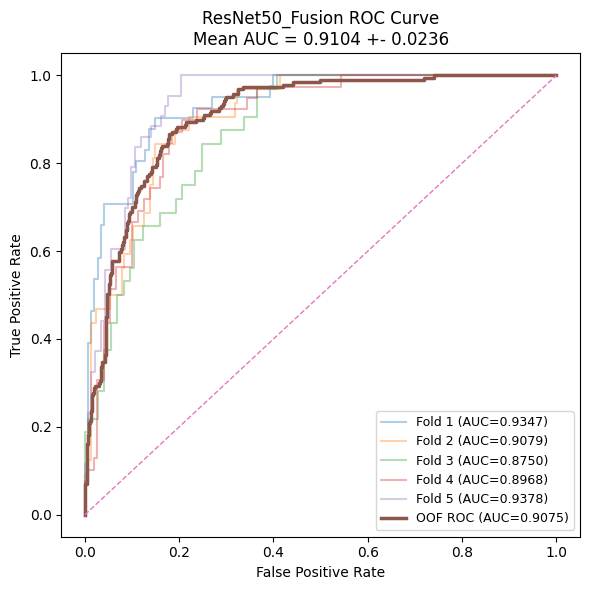

====5 fold cv roc summary === 
Fold AUCs: ['0.9347', '0.9079', '0.8750', '0.8968', '0.9378']
Mean AUC = 0.9104 +- 0.0236
OOF AUC = 0.9075
             model  fold       acc   ROC-AUC  F1-score  Sensitivity  \
0  ResNet50_Fusion     1  0.857143  0.934740  0.727273     0.878049   
1  ResNet50_Fusion     2  0.814070  0.907934  0.602151     0.875000   
2  ResNet50_Fusion     3  0.768362  0.875000  0.568421     0.843750   
3  ResNet50_Fusion     4  0.815789  0.896757  0.660194     0.871795   
4  ResNet50_Fusion     5  0.875676  0.937766  0.762887     0.860465   

       Confusion Matrix  
0  [[126, 22], [5, 36]]  
1  [[134, 33], [4, 28]]  
2  [[109, 36], [5, 27]]  
3  [[121, 30], [5, 34]]  
4  [[125, 17], [6, 37]]  
>>> Training Vit Multimodel (Mean Teacher)...

Running ViT_Fusion | Fold 1
[FOLD 1] Unlabeled 1298명 (val 513명 제외 후)
  [Labeled] total matched: 751 (pos=146, neg=605)
  [Labeled] total matched: 189 (pos=41, neg=148)
  [Unlabeled] total matched: 1298
[FOLD 1] Train labeled -> neg=

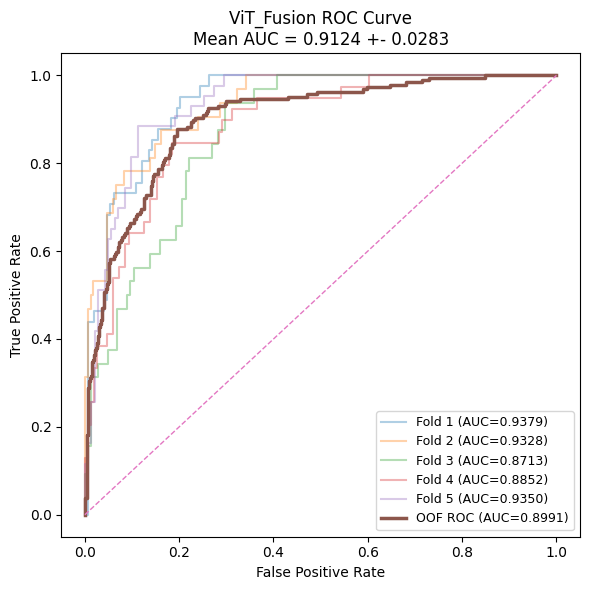

====5 fold cv roc summary === 
Fold AUCs: ['0.9379', '0.9328', '0.8713', '0.8852', '0.9350']
Mean AUC = 0.9124 +- 0.0283
OOF AUC = 0.8991
        model  fold       acc   ROC-AUC  F1-score  Sensitivity  \
0  ViT_Fusion     1  0.862434  0.937871  0.697674     0.731707   
1  ViT_Fusion     2  0.889447  0.932822  0.685714     0.750000   
2  ViT_Fusion     3  0.779661  0.871336  0.518519     0.656250   
3  ViT_Fusion     4  0.847368  0.885210  0.632911     0.641026   
4  ViT_Fusion     5  0.864865  0.934982  0.666667     0.581395   

        Confusion Matrix  
0  [[133, 15], [11, 30]]  
1   [[153, 14], [8, 24]]  
2  [[117, 28], [11, 21]]  
3  [[136, 15], [14, 25]]  
4   [[135, 7], [18, 25]]  
>>> Training Hybrid Multimodel (Mean Teacher)...

Running hybrid_Fusion | Fold 1
[FOLD 1] Unlabeled 1298명 (val 513명 제외 후)
  [Labeled] total matched: 751 (pos=146, neg=605)
  [Labeled] total matched: 189 (pos=41, neg=148)
  [Unlabeled] total matched: 1298
[FOLD 1] Train labeled -> neg=605, pos=146, pos_

In [ ]:
#14) 실행
if __name__ == "__main__":
    print(">>> Training ResNet50 Multimodel (Mean Teacher)...")
    resnet_cv_df, resnet_history_df, resnet_roc = run_cv_for_multimodal_model(
        model_name="ResNet50_Fusion",
        model_type="resnet",
        build_fn=lambda tabular_in_dim: build_resnet50_multimodal_model(tabular_in_dim = tabular_in_dim, load_pretrained=True)
    )
    print(resnet_cv_df)

    print(">>> Training Vit Multimodel (Mean Teacher)...")
    vit_cv_df, vit_history_df, vit_roc = run_cv_for_multimodal_model(
        model_name="ViT_Fusion",
        model_type="vit",
        build_fn=lambda tabular_in_dim: build_vit_multimodal_model(tabular_in_dim = tabular_in_dim, load_pretrained=True)
    )
    print(vit_cv_df)
    
    print(">>> Training Hybrid Multimodel (Mean Teacher)...")
    hybrid_cv_df, hybrid_history_df, hybrid_roc = run_cv_for_multimodal_model(
        model_name="hybrid_Fusion",
        model_type="hybrid",
        build_fn=lambda tabular_in_dim: build_hybrid_multimodal_model(tabular_in_dim = tabular_in_dim, load_pretrained=True)
    )
    print(hybrid_cv_df)

    print("\\n>> 5-Fold Summary")
    all_cv_df = pd.concat([resnet_cv_df, vit_cv_df, hybrid_cv_df], ignore_index=True)

    summary_df = (
        all_cv_df.groupby("model")[["acc", "ROC-AUC", "F1-score", "Sensitivity"]].agg(["mean", "std"])
    )

    print(summary_df)
    
    
    

In [ ]:
def run_one_multimodal_model(model_name, model_type, build_fn):
    cv_df, history_df, roc = run_cv_for_multimodal_model(
        model_name=model_name,
        model_type = model_type,
        build_fn = build_fn
    )
    display(cv_df)
    return cv_df, history_df

In [ ]:
hybrid_cv_df, hybrid_history_df, hybrid_roc = run_one_multimodal_model(
        model_name="hybrid_Fusion",
        model_type="hybrid",
        build_fn=lambda tabular_in_dim: build_hybrid_multimodal_model(tabular_in_dim = tabular_in_dim, load_pretrained=True)
    )

In [ ]:
def plot_one_model_by_fold(history_df, model_name):
    folds = sorted(history_df["fold"].unique())

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1,3,1)
    for fold in folds:
        df_fold = history_df[history_df["fold"] == fold].sort_values("epoch")
        plt.plot(df_fold["epoch"], df_fold['train_loss'], linestyle='--', alpha = 0.7, label=f'Fold{fold} Train')
        plt.plot(df_fold["epoch"], df_fold['val_loss'], alpha = 0.7, label=f'Fold{fold} Val')
    plt.title(f"{model_name} - Loss by Fold")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(fontsize=8)

    plt.subplot(1, 3, 2)
    for fold in folds:
        df_fold = history_df[history_df["fold"] == fold].sort_values("epoch")
        plt.plot(df_fold["epoch"], df_fold["val_auc"], alpha = 0.8, label = f"Fold{fold}")
    plt.title(f"{model_name} - Val ROC-AUC by Fold")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend(fontsize=8)

    plt.subplot(1, 3, 3)
    for fold in folds:
        df_fold = history_df[history_df["fold"] == fold].sort_values("epoch")
        plt.plot(df_fold["epoch"], df_fold["val_f1"], alpha = 0.8, label = f"Fold{fold}")
    plt.title(f"{model_name} - Val f1 by Fold")
    plt.xlabel("Epoch")
    plt.ylabel("f1")
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{model_name}_training_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
plot_one_model_by_fold(resnet_history_df, "ResNet50_Fusion")
plot_one_model_by_fold(vit_history_df, "ViT_Fusion")
plot_one_model_by_fold(hybrid_history_df, "hybrid_Fusion")

In [ ]:
@torch.no_grad()
def collect_predictions_multimodal(model, loader, device):
    model.eval()

    y_true, y_prob = [], []

    for imgs, tabs, labels in loader:
        imgs = imgs.to(device, non_blocking = True)
        tabs = tabs.to(device, non_blocking = True)
        labels = labels.to(device, non_blocking = True)

        logits = model(imgs, tabs)
        probs = torch.sigmoid(logits)

        y_true.extend(labels.cpu().numpy().ravel())
        y_prob.extend(probs.cpu().numpy().ravel())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(float)
    return y_true, y_prob

In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_prob, title="ROC Curve", save_path = None):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

In [ ]:
def plot_pr_curve(y_true, y_prob, title = "Precision-Recall Curve", save_path = None):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6,6))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc="lower left")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

In [ ]:
from sklearn.metrics import(
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

def _to_1d_prob(y_prob):
    y_prob = np.asarray(y_prob)

    if y_prob.ndim == 1:
        return y_prob
    elif y_prob.ndim == 2 and y_prob.shape[1] ==2:
        return y_prob[:, 1]
    else:
        raise ValueError(
            f"y_prob shape이 이상"
        )
def plot_cv_roc_pr(
    fold_results,
    figsize=(6,6),
    roc_title="5-fold cv roc curve",
    save_roc_path=None,
    show_each_fold=True,
    ddof=1
):
    fold_aucs = []
    fold_aps = []

    all_y_true = []
    all_y_prob = []

    for i, fold in enumerate(fold_results, start=1):
        y_true=np.asarray(fold["y_true"]).astype(int)
        y_prob = _to_1d_prob(fold["y_prob"])

        if len(y_true) != len(y_prob):
            raise ValueError (f" {i}번째 fold: y_true y_prod 길이가 다름")
        if len(np.unique(y_true)) < 2:
            raise ValueError(f" {i}번째 fold: y_true에 클래스가 1개만")
        fold_auc = roc_auc_score(y_true, y_prob)
        fold_ap = average_precision_score(y_true, y_prob)

        fold_aucs.append(fold_auc)
        fold_aps.append(fold_ap)

        all_y_true.append(y_true)
        all_y_prob.append(y_prob)

    all_y_true = np.concatenate(all_y_true)
    all_y_prob = np.concatenate(all_y_prob)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    oof_auc = roc_auc_score(all_y_true, all_y_prob)

    plt.figure(figsize=figsize)
    
    if show_each_fold:
        for i, fold in enumerate(fold_results, start=1):
            y_true=np.asarray(fold["y_true"]).astype(int)
            y_prob = _to_1d_prob(fold["y_prob"])

            fpr, tpr, _ = roc_curve(y_true, y_prob)
            fold_auc = roc_auc_score(y_true, y_prob)

            plt.plot(
                fpr, tpr,
                alpha=0.35,
                label=f"Fold {i} (AUC={fold_auc:.4f})"
            )

    fpr_oof, tpr_oof, _ = roc_curve(all_y_true, all_y_prob)
    plt.plot(
        fpr_oof, tpr_oof,
        linewidth=2.5,
        label=f"OOF ROC (AUC={oof_auc:.4f})"
    )
    plt.plot([0,1], [0,1], linestyle="--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{roc_title}\nMean AUC = {mean_auc:.4f} +- {std_auc:.4f}")
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()

    if save_roc_path is not None:
        plt.savefig(save_roc_path, dpi=150, bbox_inches="tight")

    plt.show()

    print("====5 fold cv roc summary === ")
    print("Fold AUCs:", [f"{x:.4f}" for x in fold_aucs])
    print(f"Mean AUC = {mean_auc:.4f} +- {std_auc:.4f}")
    print(f"OOF AUC = {oof_auc:.4f}")

    return {
        "fold_auc": fold_aucs,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "oof_auc": oof_auc
    }


In [ ]:
fold_results = [
    {"y_true": yt, "y_prob": yp}
    for yt, yp in zip(all_fold_y_true, all_fold_y_prob)
]

summary = plot_cv_roc(
    fold_results,
    roc_title="Hybrid Fusion ROC Curve",
    save_roc_path = "hybrid_5fold_roc.png",
    show_each_fold=True,
    ddof =1
)
    

In [ ]:
all_y_true = []
all_y_prob = []
fold_aucs = []
fold_aps = []

for fold in range(5):
    all_y_true.extend(y_val.tolist())
    all_y_prob.extend(y_prob.tolist())

    fold_aucs.append(roc_auc_score(y_val, y_prob))
    fold_aps.append(average_precision_score(y_val, y_prob))

print(f"Mean AUC: {np.mean(fold_aucs):.4f} +- {np.std(fold_aucs):.4f}")
print(f"Mean AP: {np.mean(fold_aps):.4f} +- {np.std(fold_aps):.4f}")

plot_roc_curve(
    np.array(all_y_true),
    np.array(all_y_prob),
    title=f"OOF ROC (mean AUC={np.mean(fold_aucs):.4f} +- {np.std(fold_aucs):.4f})"
)

plot_pr_curve(
    np.array(all_y_true),
    np.array(all_y_prob),
    title=f"OOF PR (mean AP={np.mean(fold_aps):.4f} +- {np.std(fold_aps):.4f})"
)


In [ ]:
@torch.no_grad()
def eval_ablation(model, loader, device, mode="full", threshold=0.5):
    model.eval()
    y_true, y_prob = [], []

    for imgs, tabs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        tabs = tabs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if mode == "img_only":
            tabs = torch.zeros_like(tabs)
        elif mode == "tab_only":
            imgs = torch.zeros_like(imgs)
        elif mode == "shuffled_tab":
            perm = torch.randperm(tabs.size(0), device=tabs.device)
            tabs = tabs[perm]

        logits = model(imgs, tabs)
        probs = torch.sigmoid(logits)

        y_true.extend(labels.cpu().numpy().ravel())
        y_prob.extend(probs.cpu().numpy().ravel())

    m = compute_binary_metrics(y_true, y_prob, threshold=threshold)
    print(mode, m["acc"], m["auc"], m["f1"], m["recall"])
    print(m["cm"])
    return m

best_path = OUTPUT_DIR / "ResNet50_Fusion_fold1_best.pth"
train_loader, val_loader, pos_weight, tabular_in_dim = make_fold_multimodal_loaders(1)

best_model = load_multimodal_model("resnet", best_path, device, tabular_in_dim)

eval_ablation(best_model, val_loader, device, mode="full")
eval_ablation(best_model, val_loader, device, mode="img_only")
eval_ablation(best_model, val_loader, device, mode="tab_only")
eval_ablation(best_model, val_loader, device, mode="shuffled_tab")

In [ ]:
fold_idx = 1
best_path = OUTPUT_DIR / "ResNet50_Fusion_fold1_best.pth"
train_loader, val_loader, pos_weight, tabular_in_dim = make_fold_multimodal_loaders(1)

best_model = load_multimodal_model("resnet", best_path, device, tabular_in_dim)

print("full val")
eval_loader(best_model, val_loader, device)

print("global")
shuffled_val_loader, perm = make_global_shuffled_val_loader(val_loader, seed=42)
eval_loader(best_model, shuffled_val_loader, device)

In [ ]:
class TabOverrideDataset(Dataset):
    def __init__(self, base_dataset, new_tabular_feats):
        self.base_dataset = base_dataset
        self.new_tabular_feats = np.asarray(new_tabular_feats, dtype=np.float32)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        imgs, _, labels = self.base_dataset[idx]
        tabs = torch.tensor(self.new_tabular_feats[idx], dtype=torch.float32)
        return imgs, tabs, labels

def make_global_shuffled_val_loader(val_loader, seed=42):
    base_dataset = val_loader.dataset
    rng = np.random.default_rng(seed)

    perm = rng.permutation(len(base_dataset.tabular_feats))
    shuffled_tabular_feats = base_dataset.tabular_feats[perm].copy()

    shuffled_dataset = TabOverrideDataset(base_dataset, shuffled_tabular_feats)

    shuffled_loader = DataLoader(
        shuffled_dataset,
        batch_size = val_loader.batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
        drop_last = False
    )

    return shuffled_loader, perm

@torch.no_grad()
def eval_loader(model, loader, device, threshold=0.5):
    model.eval()
    y_true, y_prob = [], []

    for imgs, tabs, labels in loader:
        imgs = imgs.to(device, non_blocking = True)
        tabs = tabs.to(device, non_blocking = True)
        labels = labels.to(device, non_blocking = True)

        logits = model(imgs, tabs)
        probs = torch.sigmoid(logits)

        y_true.extend(labels.cpu().numpy().ravel())
        y_prob.extend(probs.cpu().numpy().ravel())

    m = compute_binary_metrics(y_true, y_prob, threshold=threshold)
    print("acc:", m["acc"], "auc:", m["auc"], "f1:", m["f1"], m["recall"])
    print(m["cm"])
    return m

In [ ]:
fold_idx = 1
train_loader, val_loader, pos_weight, tabular_in_dim = make_fold_multimodal_loaders(fold_idx)

print("train dataset len:", len(train_loader.dataset))
print("val dataset len:", len(val_loader.dataset))

val_labels = [val_loader.dataset.labels[i] for i in val_loader.dataset.indices]
val_labels = np.array(val_labels).astype(int)

print("val benign:", (val_labels == 0).sum())
print("val malignant:", (val_labels == 1).sum())

In [ ]:
fold_idx = 1

train_tab = TABULAR_STAGE1_DF[
    (TABULAR_STAGE1_DF["fold"] == fold_idx) & (TABULAR_STAGE1_DF["split"] == "train")
].copy()
val_tab = TABULAR_STAGE1_DF[
    (TABULAR_STAGE1_DF["fold"] == fold_idx) & (TABULAR_STAGE1_DF["split"] == "val")
].copy()

train_ids = set(train_tab["PT_ID"].astype(str))
val_ids = set(val_tab["PT_ID"].astype(str))

print("TAB overlap:", len(train_ids & val_ids))
print(list(sorted(train_ids & val_ids))[:20])

In [ ]:
def plot_confusion_matrices_paper(model_info_list, save_path=None):
    n = len(model_info_list)
    ncols = 3
    nrow = (n + ncols -1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = axes.flatten()

    for i, info in enumerate(model_info_list):
        y_pred = (np.array(info["y_prob"]) > 0.5).astype(int)
        cm = confusion_matrix(info["y_true"], y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["Benign", "Malignant"])
        disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
        auc_val = roc_auc_score(info["y_true"], info["y_prob"])
        acc_val = accuracy_score(info["y_true"], y_pred)
        sens_val = recall_score(info["y_true"], y_pred, zero_division=0)
        axes[i].set_title(
            f'{infl["name"]}\nACC={acc_val:.3f}  AUC={auc_val:.3f}  Sens={sens_val:.3f}',
            fontsize=10, fontweight='bold'
        )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    fig.suptitle("Confusion Matrics - CT Binary Classification",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Confusion matrix figure saved -> {save_path}")
    plt.show()
    return fig

In [ ]:
def check_data_leakage(fold_idx):
    train_tab_df = TABULAR_STAGE1_DF[
        (TABULAR_STAGE1_DF["fold"] == fold_idx) &
        (TABULAR_STAGE1_DF["split"] == "train") 
    ]
    val_tab_df = TABULAR_STAGE1_DF[
        (TABULAR_STAGE1_DF["fold"] == fold_idx) &
        (TABULAR_STAGE1_DF["split"] == "val") 
    ]
    unlabeled_tab_df = TABULAR_STAGE1_DF[
        (TABULAR_STAGE1_DF["recurrence"] == -1) &
        (TABULAR_STAGE1_DF["fold"] == fold_idx) &
        (TABULAR_STAGE1_DF["split"] == "train") 
    ]

    val_ids = set(val_tab_df["PT_ID"].astype(str))
    unlabeled_ids = set(unlabeled_tab_df["PT_ID"].astype(str))

    leakage = val_ids & unlabeled_ids
    print(f"[Fold {fold_idx}] Val 환자 수 : {len(val_ids)}")
    print(f"[Fold {fold_idx}] Unlabeled 환자 수 : {len(unlabeled_ids)}")
    print(f"[Fold {fold_idx}] 누수 환자 수 : {len(leakage)}")
    if leakage:
        print(f"  -> 누수 환자 ID 샘플: {list(leakage)[:5]}")

for fold_idx in FOLDS:
        check_data_leakage(fold_idx)


In [ ]:
print("전체 recurrence == -1 환자 수:",
      TABULAR_STAGE1_DF[
          TABULAR_STAGE1_DF["recurrence"] == -1
      ]["PT_ID"].nunique())

print(" 전체 recurrence == -1 행 수 (중복 포함):",
      len(TABULAR_STAGE1_DF[
          TABULAR_STAGE1_DF["recurrence"] == -1
      ]))


print("전체 DF에서 PT_ID 중복 여부:")
print(TABULAR_STAGE1_DF["PT_ID"].duplicated().sum(), "개 중복")

In [ ]:
print(TABULAR_STAGE1_DF.groupby("PT_ID").size().describe())
print(TABULAR_STAGE1_DF[["PT_ID", "fold", "split", "recurrence"]].head(20))